# Project Description

The goal of this project is to predict how likely a borrower is to default on a loan using demographic, financial, and loan-related features.

The target variable is "loan_status" with it having two values:
1. 0 = loan has been paid back
2. 1 = load was defaulted

This is a Binary Classification because there are only two outcomes, namely: default vs non-default.

# Imports/Dependencies

# Important Libraries

- <b><u>Pandas</u></b>: Used to handle the dataset and helps with cleaning and processing.
- <b><u>MathPlotLib</b> and Seaborn</u>: Used for data visualization and gaining a better insight.
- <b><u>Sklearn</u></b>: This module has various libraries with implemented models which can be user for data evaluation

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, classification_report, log_loss, auc, precision_recall_curve

# Loading and inspecting the dataset

In [61]:
financialDF = pd.read_csv('credit_risk_dataset.csv')

# Learning the Data

In [62]:
# view the first 10 rows of the dataset
financialDF.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [63]:
# check what columns are in the dataset
list(financialDF.columns)

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [64]:
print(f"The shape of the dataframe is: {financialDF.shape}\n")

The shape of the dataframe is: (32581, 12)



In [65]:
print(f"The info of the dataframe is:\n{financialDF.info()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
The info of the dataframe is:
N

In [66]:
print("Description of the dataset:")
financialDF.describe()

Description of the dataset:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


loan_status
0    25473
1     7108
Name: count, dtype: int64


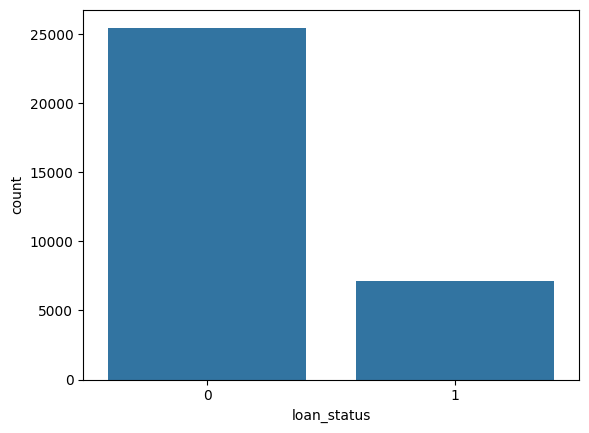

In [67]:
print(financialDF['loan_status'].value_counts())
sns.countplot(x='loan_status', data=financialDF)
plt.show()

# Data Analysis and Cleaning

1. Removing all rows with <u>**NULL**</u> values

In [68]:
# number of empty cells per column before cleaning
print(financialDF.isnull().sum(), f"Original shape of dataframe{financialDF.shape}") # (32561,12)

# remove any row that has a missing value
financialDF.dropna(inplace=True)

print("--------------------------------------------")

# number of empty cells per column after cleaning
print(financialDF.isnull().sum(), f"Shape of updated dataframe{financialDF.shape}") # (28638, 12)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64 Original shape of dataframe(32581, 12)
--------------------------------------------
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64 Shape of updated dataframe(28638, 12)


2. Removing <u>**Duplicate**</u> values

In [69]:
financialDF.drop_duplicates(inplace=True)

print(f"Shape of updated dataframe{financialDF.shape}")

Shape of updated dataframe(28501, 12)


3. Removing any <u>**outliers**</u>

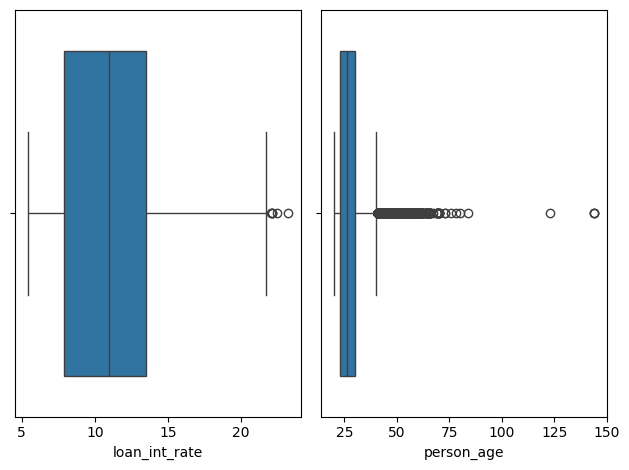

In [70]:
plt.subplot(1, 2, 1)
sns.boxplot(x=financialDF['loan_int_rate'])

plt.subplot(1, 2, 2)
sns.boxplot(x=financialDF['person_age'])

plt.tight_layout()
plt.show()

We can observe that there are some extreme/unrealistic outliers for the age. Thus, I will remove the outliers for any age > 120

In [71]:
# remove outliers

print("Shape before dealing with outliers: ", financialDF.shape)

financialDF = financialDF[financialDF["person_age"] <= 100]
financialDF = financialDF[financialDF["person_emp_length"] <= 60]

income_99th = financialDF["person_income"].quantile(0.99)
financialDF["person_income"] = np.where(financialDF["person_income"] > income_99th, income_99th, financialDF["person_income"])

print("Shape after dealing with outliers: ", financialDF.shape)


Shape before dealing with outliers:  (28501, 12)
Shape after dealing with outliers:  (28495, 12)


# Exploratory Data Analysis

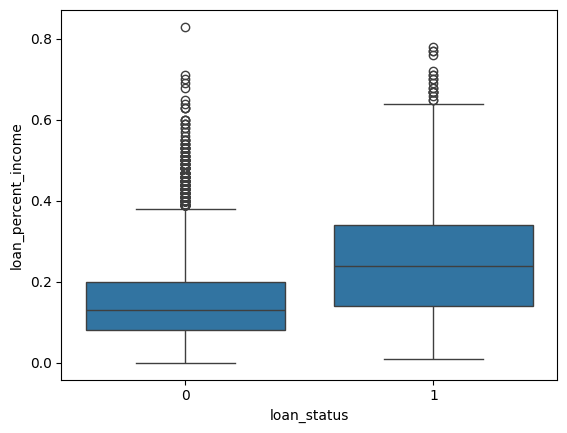

In [72]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=financialDF)
plt.show()

<Axes: xlabel='loan_grade', ylabel='count'>

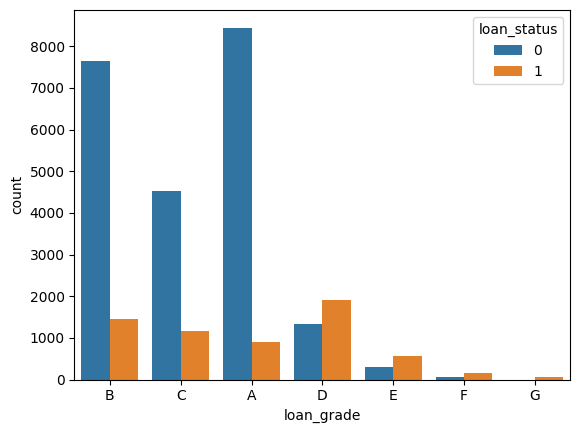

In [73]:
sns.countplot(x='loan_grade', hue='loan_status', data=financialDF)

<Axes: >

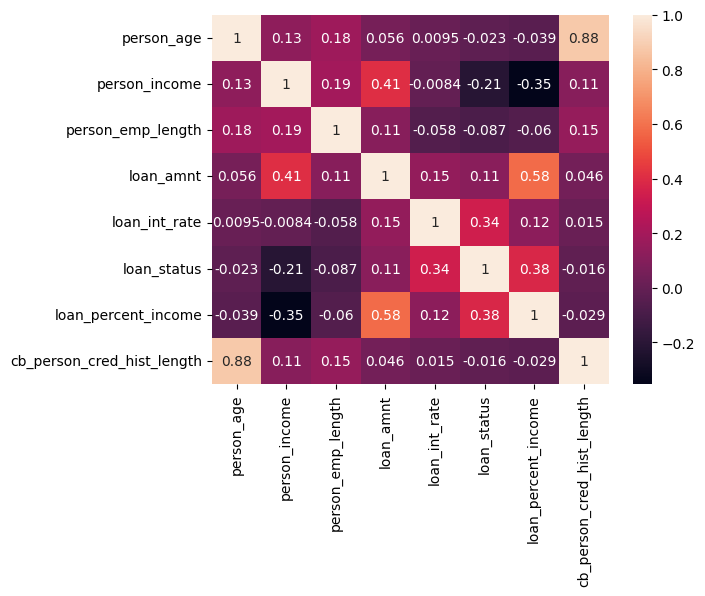

In [74]:
corr = financialDF.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Creating a correlation heatmap of the dataset shows that for "loan_status", factors that show a strong correlation include: 
1. <u><b>loan_percent_income</b></u> (Positive Correlation): Those whose loan is a larger percent of their income are more likely to default on a loan
2. <u><b>loan_int_rate</b></u> (Positive Correlation): The higher the interest rate of a person, the more likely they are to default on their loan
3. <u><b>person_income</b></u> (Negative Correlation): The more someone makes, the less likely they are to defaulr on their loan
4. <u><b>loan_amount</b></u> (Positive Correlation): The higher the loan amount, the more likely the person is to default on the loan

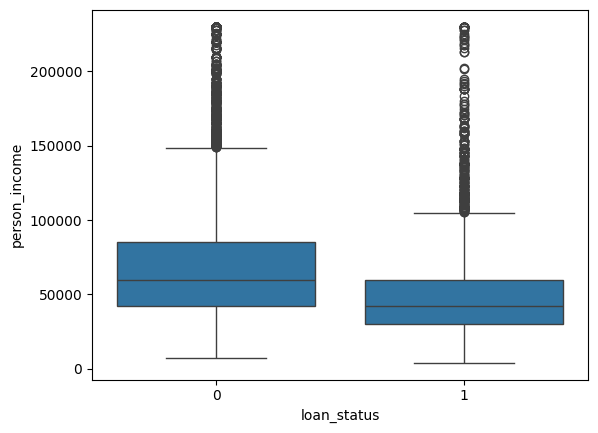

In [75]:
sns.boxplot(x='loan_status', y='person_income', data=financialDF)
plt.show()


Observation: Dafulters tend to have lower income compared to those who don't defualt. Furthermore, huge number of outliers reveals that the data is right skewed.

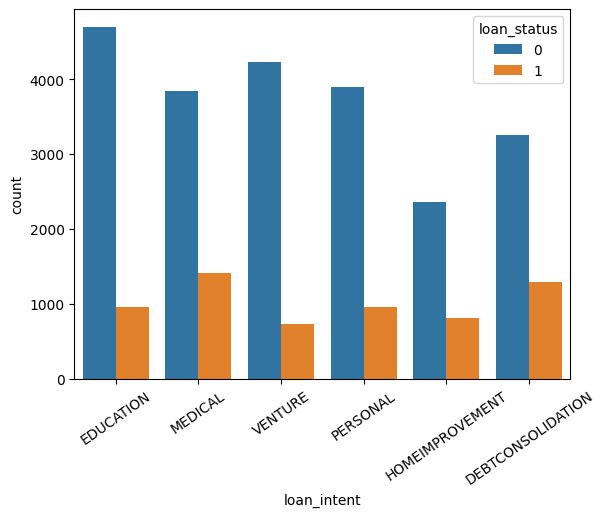

In [76]:
# loan status vs loan intent
sns.countplot(x='loan_intent', hue='loan_status', data=financialDF)
plt.xticks(rotation = 35)
plt.show()

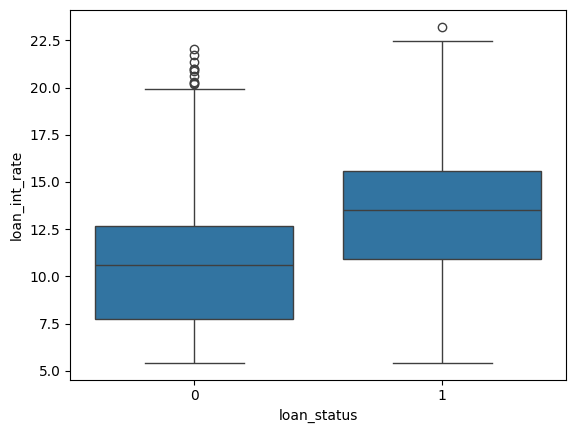

In [77]:
# loan interest rate vs loan status
sns.boxplot(x='loan_status', y='loan_int_rate', data=financialDF)
plt.show()

Observation: Those who did not default generally had a lower interest rate. This suggests that a higher interest rate is associated with an increased default risk.

# Model Training and Analysis

### Logistic Regression

I choose to use Logistic Regression, which is a statistical model and classigication algorithm, as I am trying to predict a discrete category, namely loan_status.

In [78]:
# every attribute which could contribute to the prediction
X = financialDF.drop('loan_status', axis=1)

# attribute to predict
y = financialDF['loan_status']


# this encodes the object/categorical variables, so the model can deal with these values
X = pd.get_dummies(X, drop_first=True)

# 60/40 training/testing split
# random_state ensures reproductability
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


# standardizes features because Logistic Regression is sensitive to Feature Magnitude
scaler_var = StandardScaler()
X_train = scaler_var.fit_transform(x_train)
X_test = scaler_var.transform(x_test)


In [79]:

# Traing the Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


# Make the prediction for the testing dataset
y_pred = lr_model.predict(X_test)


### Evalute the performance of the Logistic Regression Model

In [80]:
# Accuracy:
acc = accuracy_score(y_test, y_pred) * 100
print(f"accuracy: {round(acc, 2)}%\n")
print(f"Precentage of non-defults: {(len(financialDF[financialDF["loan_status"] == 0])/len(financialDF["loan_status"])) * 100:.2f}%\n")
print(f"Precentage of defults: {(len(financialDF[financialDF["loan_status"] == 1])/len(financialDF["loan_status"])) * 100:.2f}%\n")


# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), end="\n")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


y_scores = lr_model.predict_proba(X_test)[:, 1]

precision, recall, threshold = precision_recall_curve(y_test, y_scores)

auc_score = auc(recall, precision)

print(f"auc_score: {auc_score}")

accuracy: 86.66%

Precentage of non-defults: 78.29%

Precentage of defults: 21.71%

Confusion Matrix:
[[8485  416]
 [1104 1393]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      8901
           1       0.77      0.56      0.65      2497

    accuracy                           0.87     11398
   macro avg       0.83      0.76      0.78     11398
weighted avg       0.86      0.87      0.86     11398

auc_score: 0.7300778955437346


The accuracy of the Logistic Regression model is 86.66% which is pretty high. Furthermore, through the EDA, we can observe that there is a higher amount of non-defulats than defaults. The percentage of non-defaults is 78.29% which is lower than the accuracy of the model. This is important becauase it is necessary to check if the model is just consistantly guessing one answer and having a high accuracy. For instance, if it always guessed non-defulat. it could have a 78.29% accuracy.

The model guessing yes, would indicate the the borrower would indeed default on the loan. Based off the Confusion Matrix and Classification Report, it can be identified that the model the False Negative is relatively high. This means that the model guessed the borrower would not defualt when they actually would. This is determental because it can lead to lending money to someone who is unlikely ot be able to pay it back.

Furthermore, the recall score supports this as for non-defaults is is 95% accurate and for defaults it is 56% accurate. This supports the finding that the model is imbalanced and guesses towards non-defaults frequently, thereby missing a lot of real default cases.

However, according to the precision score of 77%, the model often predicts correctly when it predict a default.

The AUC-Score suggest that this model is not entirely bad.

/var/folders/qm/w6dbq0kd6tb78c2rm_8fhc7w0000gn/T/ipykernel_31485/1244753958.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


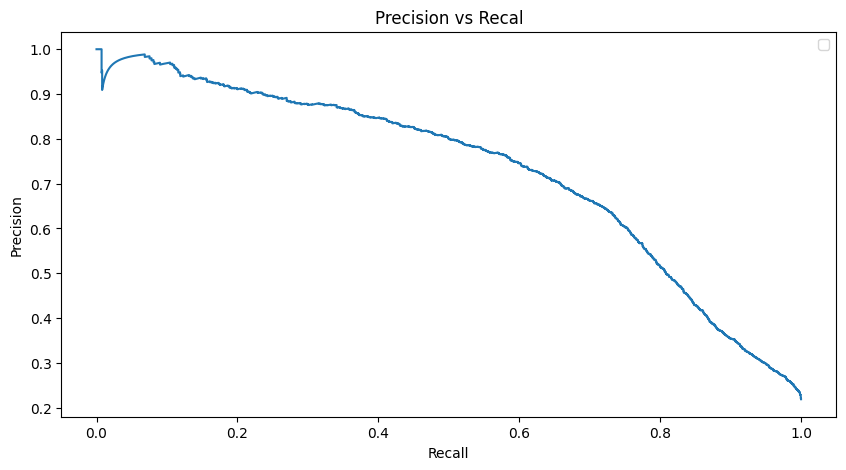

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recal')
plt.legend()
plt.show()

This graph shows that the more the model predicted

### Decision Tree

In [82]:
# Using GridSearch along with the DecisionTreeClassifier to test multiple max_depths and select the best performing option through cross-validation
# dealing with the best max_depth to prevent overfitting

tree_model = DecisionTreeClassifier(random_state=5)

# list of depths to test
depth_test = {'max_depth' : [2, 3, 5, 7, 9, 10, None]}

# split dataset into 5 parts to validate each depth
determined_depth = GridSearchCV(estimator=tree_model, param_grid=depth_test, cv = 5, scoring="roc_auc")

# fitting the data
determined_depth.fit(X_train, y_train)

# finding the best depth
print(f"Best Depth: {determined_depth.best_params_['max_depth']}")
print(f"Best CV AUC: {determined_depth.best_score_:.4f}")

# best fitted tree
best_tree = determined_depth.best_estimator_

# class predictions
dt_prediction = determined_depth.predict(X_test)

# probability predictions for AUC
dt_proba = best_tree.predict_proba(X_test)[:, 1]



Best Depth: 7
Best CV AUC: 0.8982


### Decision Tree Analysis

In [83]:
# train_acc = determined_depth.score(X_train, y_train)
# test_acc = determined_depth.score(X_test, y_test)
prediction_accuracy = accuracy_score(y_test, dt_prediction)

# print(f"Train Accuracy: {train_acc:.4f}")
# print(f"Test Accuracy: {test_acc:.4f}\n")
print(f"Prediction Accuracy: {prediction_accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_prediction))

print("\nClassification Report:")
print(classification_report(y_test, dt_prediction))

precision, recall, threshold = precision_recall_curve(y_test, dt_proba)
dt_pr_auc = auc(recall, precision)
print(f"PR AUC Score: {dt_pr_auc:.4f}")

Prediction Accuracy: 0.9138

Confusion Matrix:
[[8794  107]
 [ 876 1621]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      8901
           1       0.94      0.65      0.77      2497

    accuracy                           0.91     11398
   macro avg       0.92      0.82      0.86     11398
weighted avg       0.92      0.91      0.91     11398

PR AUC Score: 0.8420


The accuracy of the Decision Tree model is 92% which is higher than that of the Logistic Regression Model. This indicated that this Decision Tree model is probably better at accurately predicting when the <b>loan_status</b> defaults and is less likely to just guess a non-defualt when compared to the Logistic Regression Model.

This is further backed up when observing the confusion matrix and classification report. The False Negative in the confusion matrix decreased by quite a bit, revealing a decrease in the number of non-defualts guessed which were wrong. Also, the predicion and recall score for a default significantly increased meaning it is more accurate when prediting a default on the loan.

A more in-depth analysis of the classification report reveals that the model has high precision but a relatively lower recall score because it only deciding a default when it is extermly sure that it would be correct. The recall score for non-default went up, supporting the idea that unless extremely sure, it does not decide on a default.

In summary, this model guesses less and is significnlty more accurate in comparison to the previous model and would be better when trying to identify eligible candidates to provide a loan given the same attributes observed in the dataset.

In [84]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': determined_depth.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                        Feature  Importance
5           loan_percent_income    0.328057
4                 loan_int_rate    0.208184
9    person_home_ownership_RENT    0.200696
1                 person_income    0.088508
17                 loan_grade_D    0.036338
12          loan_intent_MEDICAL    0.035885
2             person_emp_length    0.031251
16                 loan_grade_C    0.029968
8     person_home_ownership_OWN    0.012427
11  loan_intent_HOMEIMPROVEMENT    0.008651


The Decision Tree model ranks the 

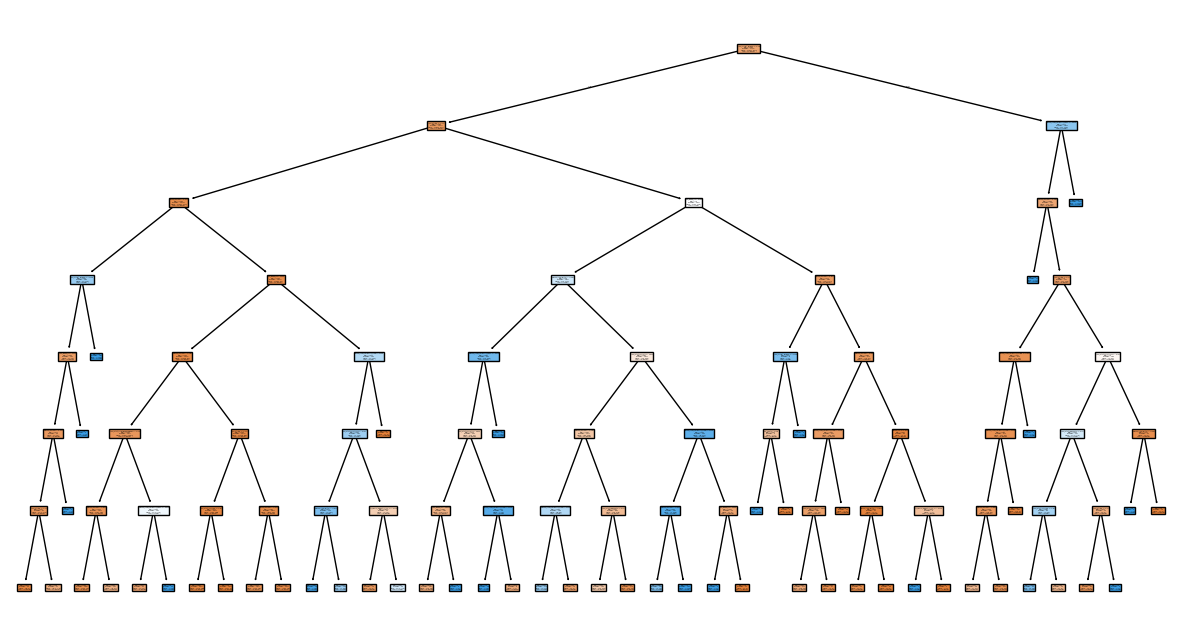

In [85]:
plt.figure(figsize=(15,8))

plot_tree(
    determined_depth.best_estimator_,
    filled=True,
    feature_names=x_train.columns,
    class_names=["No Default", "Default"]
)

plt.show()

### Random Forest

In [86]:
# TODO: Include a Random Forest Algorithm

rf_model = RandomForestClassifier(n_estimators=100, random_state=1)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

In [87]:
rf_acc = accuracy_score(y_test, rf_prediction) * 100
print(f"Random Forest Accuracy: {rf_acc:.2f}%")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_prediction))

# Classification report
print("Classification Report:")
print(classification_report(y_test, rf_prediction))

# Precision-recall AUC
rf_scores = rf_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, rf_scores)
rf_auc = auc(recall, precision)

print(f"Random Forest PR-AUC: {rf_auc:.4f}")

Random Forest Accuracy: 92.95%
Confusion Matrix:
[[8791  110]
 [ 693 1804]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      8901
           1       0.94      0.72      0.82      2497

    accuracy                           0.93     11398
   macro avg       0.93      0.86      0.89     11398
weighted avg       0.93      0.93      0.93     11398

Random Forest PR-AUC: 0.8809


The Random Forest Model performs better in almost all aspects such as accuracy, precision and recall value compared to the Decision Tree Model, although not by very much. Its AUC score is also higher, meaning it has a better understanding of the data and is able to more accurately distinguish between if a borrower would default or not.

We can see the improvements continue when comparing their confusion matrices, as its False Positive and False Negative values are also lower than that of the Decision Tree Model.

In [88]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

                       Feature  Importance
5          loan_percent_income    0.216138
1                person_income    0.139324
4                loan_int_rate    0.134930
3                    loan_amnt    0.080534
9   person_home_ownership_RENT    0.072538
17                loan_grade_D    0.062850
2            person_emp_length    0.060105
0                   person_age    0.048538
6   cb_person_cred_hist_length    0.037806
8    person_home_ownership_OWN    0.018347


Importance Analysis:

During EDA, loan_percent_income and loan_int_rate showed strong relationships with default status. The Random Forest model also ranked these features among the most important predictors, thus supporting the patterns identified during exploratory analysis.

All models compared:



| Model | Acuracy | Precision (default)| Recall | F1 | PR-AUC |
| --- | --- | --- | --- | --- | --- |
| Logistic Regression | 0.8666 | 0.77 | 0.56 | 0.65 | 0.73 |
| Decision Tree | 0.9222 | 0.92 | 0.70 | 0.80| 0.842 |
| Random Forest | 0.9295 | 0.94 | 0.72 | 0.82 | 0.8809 |




The Random Forest model performed best because it is able to map complex, non-linear relationships. Compared to a single decision tree which easily overfits and logistic regression which is limited to linear assumptions, the random forest combines many decision trees and thereby reduces the overfitting that can be experienced in a single decision tree.

Final Recommendation :

If I was a real lender, I would choose to go with the Random Forest Model in order to determined who to lend to. This model shows to have the highest accuracy, precision, and recall values compared to the Decision Tree and Logistic Regression Models. Therefore, it would be the prefered model to identify high rist borrowers and prevent lending money to those who are likely to default on their loan, and would be a useful tool to aid in maximazing profit.